### В данном уроке мы выделим еще несколько потенциально важных фичей из изначального датасета и попробуем применить изученные методы отбора признаков к итоговому датасету.

In [1]:
import numpy as np
import pandas as pd

processed_data = pd.read_csv('processed_data.csv', index_col='id')

processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration
id,,,,,
id2875421,1,930.399753,0,1.500479,6.122493
id2377394,0,930.399753,0,1.807119,6.498282
id3858529,1,930.399753,0,6.392080,7.661527
id3504673,1,930.399753,0,1.487155,6.063785
id2181028,1,930.399753,0,1.189925,6.077642


In [2]:
initial_data = pd.read_csv('taxi_dataset.csv')

initial_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N


In [3]:
initial_data.shape[0] == processed_data.shape[0]

True

In [4]:
### Вернем в датасет колонку pickup_datetime

initial_data = initial_data.set_index('id')

processed_data = pd.merge(processed_data, initial_data['pickup_datetime'],
                          left_index=True, right_index=True)

In [5]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,pickup_datetime
id,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,2016-03-14 17:24:55
id2377394,0,930.399753,0,1.807119,6.498282,2016-06-12 00:43:35
id3858529,1,930.399753,0,6.392080,7.661527,2016-01-19 11:35:24
id3504673,1,930.399753,0,1.487155,6.063785,2016-04-06 19:32:31
id2181028,1,930.399753,0,1.189925,6.077642,2016-03-26 13:30:55


Напомним, **pickup_datetime** - время начала поездки.

Кажется, что в зависимости от месяца/дня недели/времени суток движение на дорогах может отличаться. Как из-за погодных условий, так и из-за загруженности транспорта. Поэтому, есть подозрение, что будет полезно выделить ряд признаков из колонки **pickup_datetime**. Давайте исследуем зависимость нашей таргетной переменной от указанных факторов.

In [6]:
processed_data['pickup_datetime'] = pd.to_datetime(processed_data['pickup_datetime'])

processed_data['date'] = processed_data.pickup_datetime.dt.date
processed_data['day_of_week'] = processed_data.pickup_datetime.dt.dayofweek
processed_data['hour'] = processed_data.pickup_datetime.dt.hour
processed_data['month'] = processed_data.pickup_datetime.dt.month

In [7]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,pickup_datetime,date,day_of_week,hour,month
id,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,2016-03-14 17:24:55,2016-03-14,0,17,3
id2377394,0,930.399753,0,1.807119,6.498282,2016-06-12 00:43:35,2016-06-12,6,0,6
id3858529,1,930.399753,0,6.392080,7.661527,2016-01-19 11:35:24,2016-01-19,1,11,1
id3504673,1,930.399753,0,1.487155,6.063785,2016-04-06 19:32:31,2016-04-06,2,19,4
id2181028,1,930.399753,0,1.189925,6.077642,2016-03-26 13:30:55,2016-03-26,5,13,3


Исследуем, когда и сколько поездок было совершено. 

Начнем с графиков, показывающих количество поездок в зависимости от времени суток/даты и т.д.

Так же полезно сразу показать и среднее значение таргетной переменной.

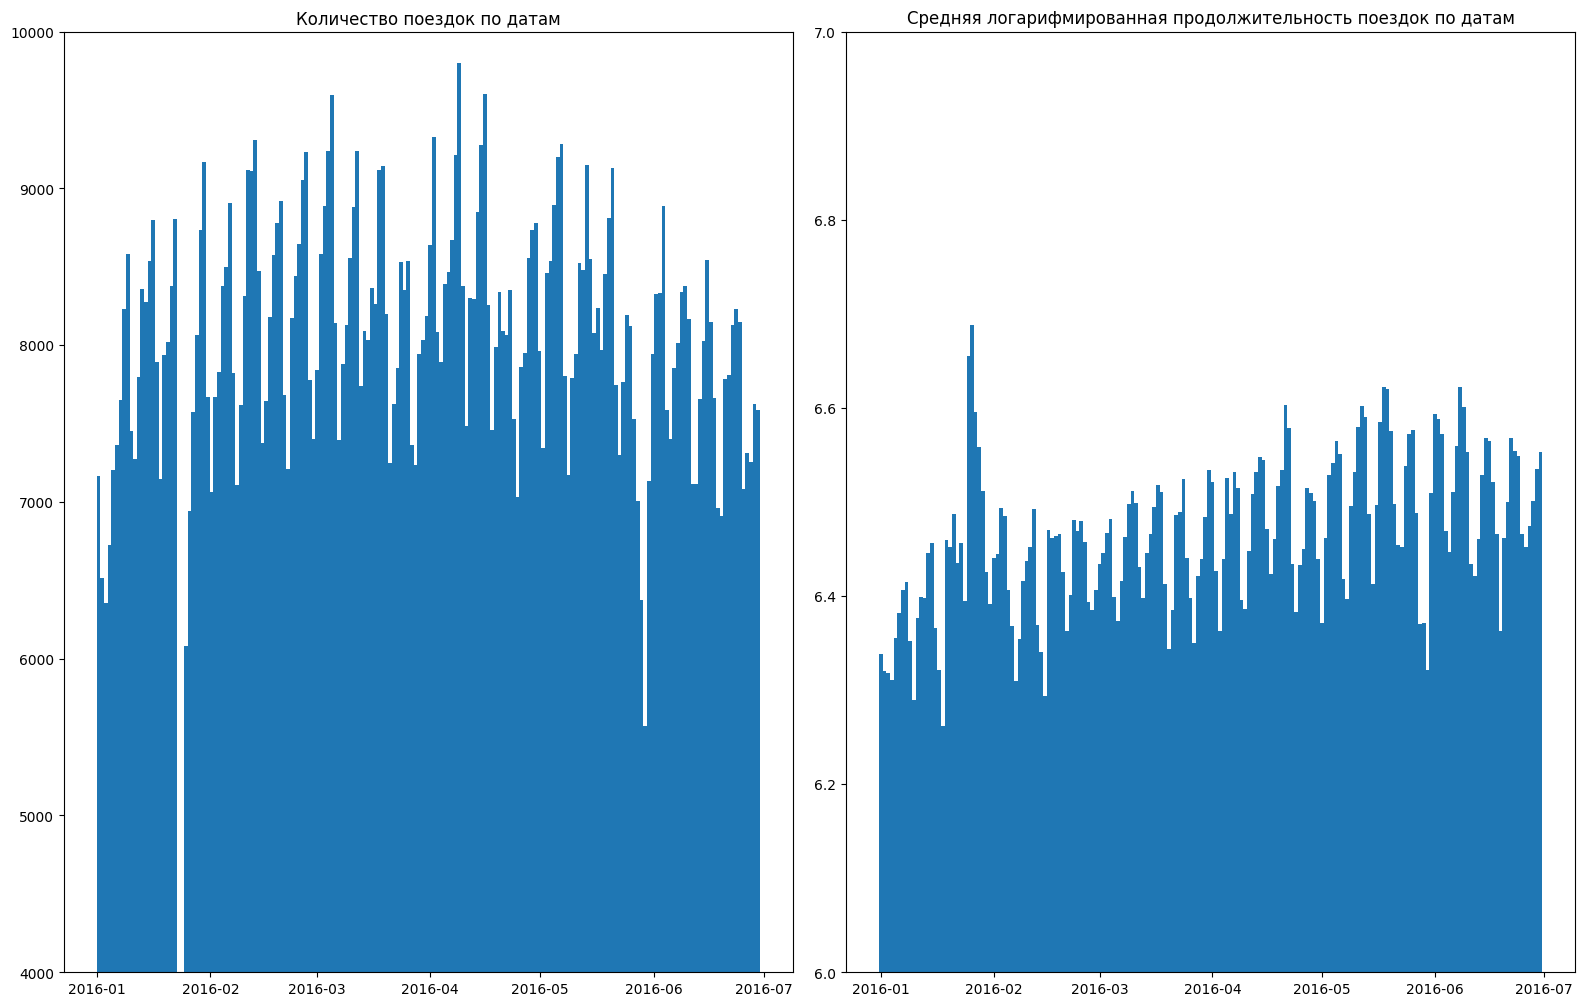

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure()

fig.set_size_inches(16, 10)

ax_1 = fig.add_subplot(1, 2, 1)
plt.hist(processed_data['date'], bins=processed_data.date.unique().shape[0])
plt.ylim((4000, 10000))

ax_2 = fig.add_subplot(1, 2, 2)
plt.bar(sorted(list(processed_data['date'].unique())), 
        processed_data.groupby('date', as_index=False)['log_trip_duration'].mean()['log_trip_duration'],
        width=1)
plt.ylim((6, 7))

fig.tight_layout()

ax_1.set(title = 'Количество поездок по датам')
ax_2.set(title = 'Средняя логарифмированная продолжительность поездок по датам')

plt.show()

In [9]:
# processed_data[processed_data['date'].isin(['2016-01-18', '2016-01-19', '2016-01-20', '2016-01-21', '2016-01-22', '2016-01-23', '2016-01-24'])].groupby('date')['log_trip_duration'].mean()
dates = pd.to_datetime(processed_data['date'])
processed_data[dates.between('2016-01-18', '2016-01-26')].groupby('date')['log_trip_duration'].count()


date
2016-01-18    7146
2016-01-19    7934
2016-01-20    8018
2016-01-21    8375
2016-01-22    8805
2016-01-23    1648
2016-01-24    3383
2016-01-25    6084
2016-01-26    6941
Name: log_trip_duration, dtype: int64

Кажется, что внутри недели есть некоторая зависимость таргета от дня недели. 

Такая же зависимость может оказаться и внутри дня (в завимости от часов).

Предлагаю исследовать эту зависимость подробнее.

Изобразите следующие графики зависимостей:

- Количество поездок/Средняя продолжительность поездки vs День недели
- Количество поездок/Средняя продолжительность поездки vs время суток
- Средняя продолжительность поездки vs время суток для каждого дня недели (например, нарисовав с разными цветами и, соответственно, легендами)
- Аналогичные графики, используя информацию о месяце, внутри которого была совершена поездка.
- Ящики с усами для различных: времени суток, дня недели, месяца

Используйте любые доступные инструменты pyplot!

Далее, на основе полученных результатов, мы будем принимать решение о создании новых признаков.

EDA можно использовать не только для того, чтобы понять, какие фичи можно убрать из датасета. Но и для выделения базовых признаков. Этим и займемся!

P.S. Сами графики мы проверять у Вас не будем. Зато для ответа на устные вопросы понадобятся, поэтому, в любом случае, крайне рекомендуем поупражняться. Поэтому рисовать все графики не обязательно - ограничьтесь теми, которые помогут Вам ответить на тестовые вопросы.

**Hint**: обратите внимание на сильную просадку в январе. Почему она могла произойти - можно прочитать <a href="https://en.wikipedia.org/wiki/January_2016_United_States_blizzard"> здесь</a>. В будущем можно будет создать бинарный признак "произошла ли поездка во время сильного снегопада".


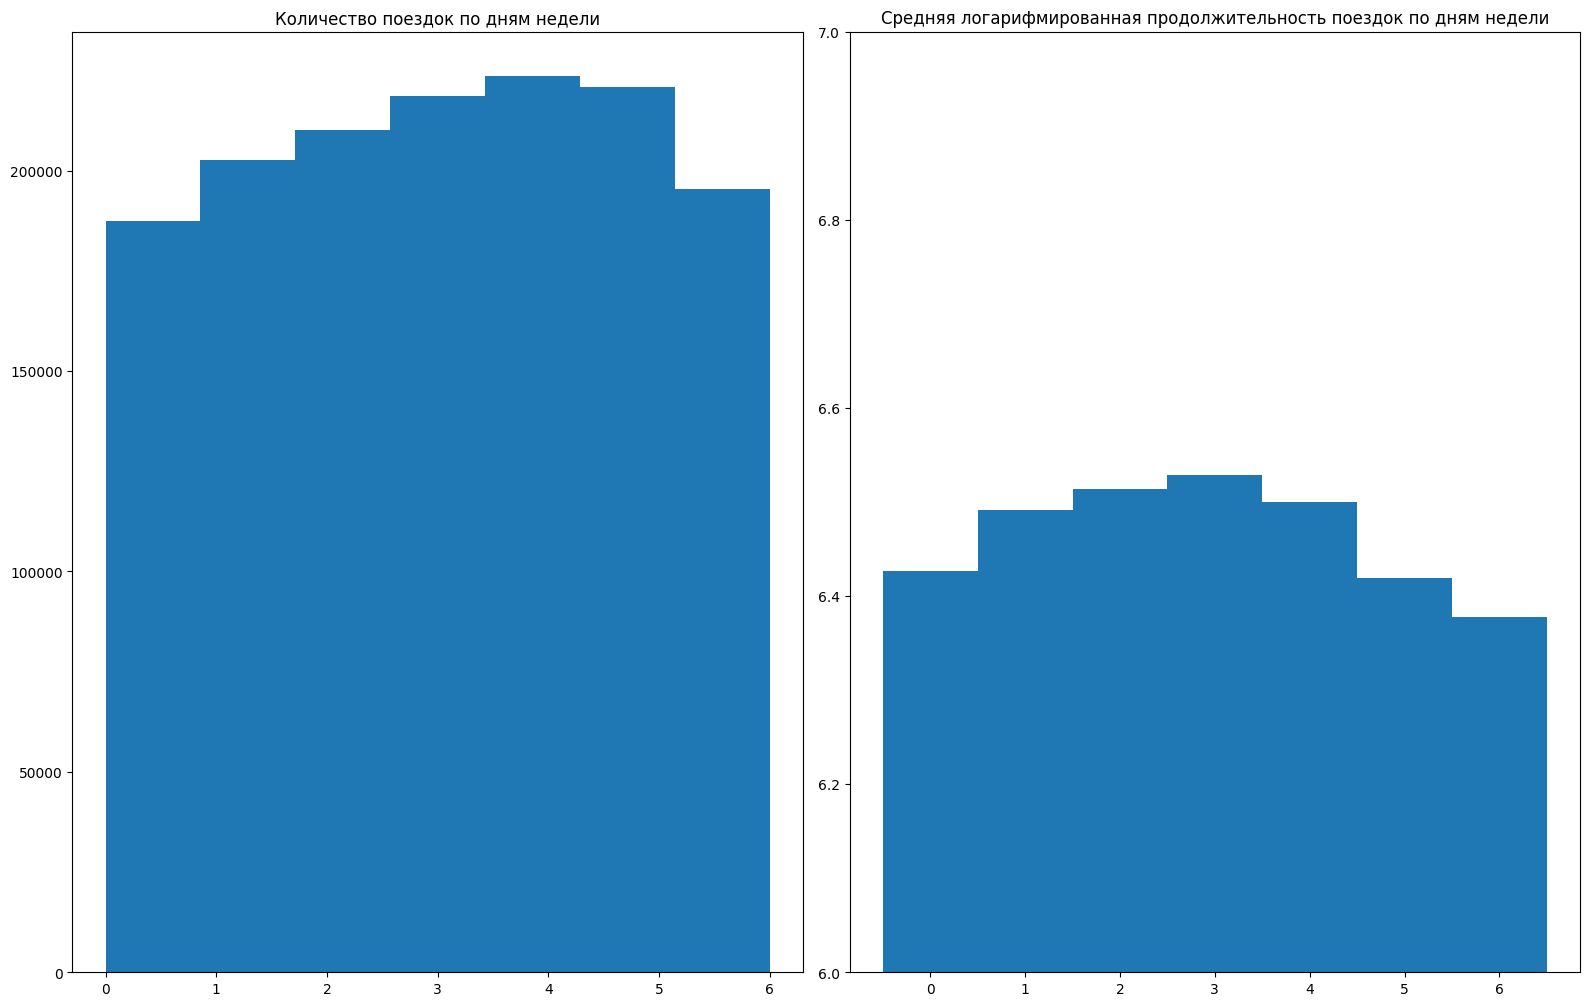

In [10]:
import matplotlib.pyplot as plt

fig = plt.figure()

fig.set_size_inches(16, 10)

ax_1 = fig.add_subplot(1, 2, 1)
plt.hist(processed_data['day_of_week'], bins=processed_data.day_of_week.unique().shape[0])
# plt.ylim((4000, 100000))

ax_2 = fig.add_subplot(1, 2, 2)
plt.bar(sorted(list(processed_data['day_of_week'].unique())), 
        processed_data.groupby('day_of_week', as_index=False)['log_trip_duration'].mean()['log_trip_duration'],
        width=1)
plt.ylim((6, 7))

fig.tight_layout()

ax_1.set(title = 'Количество поездок по дням недели')
ax_2.set(title = 'Средняя логарифмированная продолжительность поездок по дням недели')

plt.show()




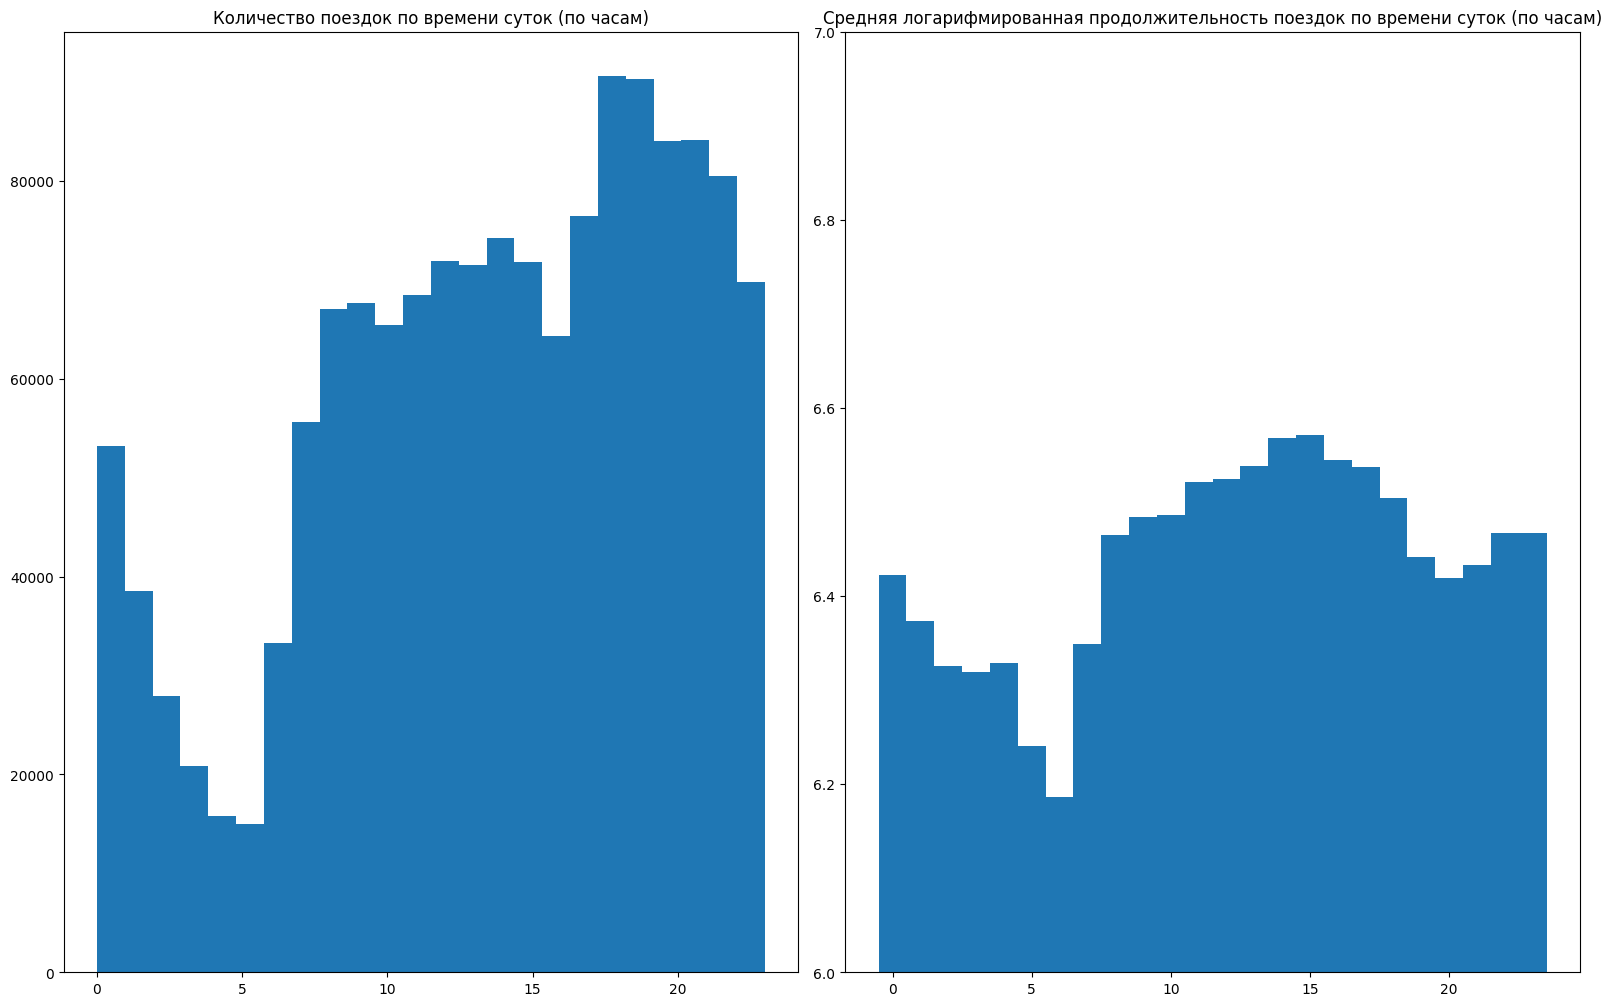

In [11]:
import matplotlib.pyplot as plt

fig = plt.figure()

fig.set_size_inches(16, 10)

ax_1 = fig.add_subplot(1, 2, 1)
plt.hist(processed_data['hour'], bins=processed_data.hour.unique().shape[0])
# plt.ylim((4000, 100000))

ax_2 = fig.add_subplot(1, 2, 2)
plt.bar(sorted(list(processed_data['hour'].unique())), 
        processed_data.groupby('hour', as_index=False)['log_trip_duration'].mean()['log_trip_duration'],
        width=1)
plt.ylim((6, 7))

fig.tight_layout()

ax_1.set(title = 'Количество поездок по времени суток (по часам)')
ax_2.set(title = 'Средняя логарифмированная продолжительность поездок по времени суток (по часам)')

plt.show()

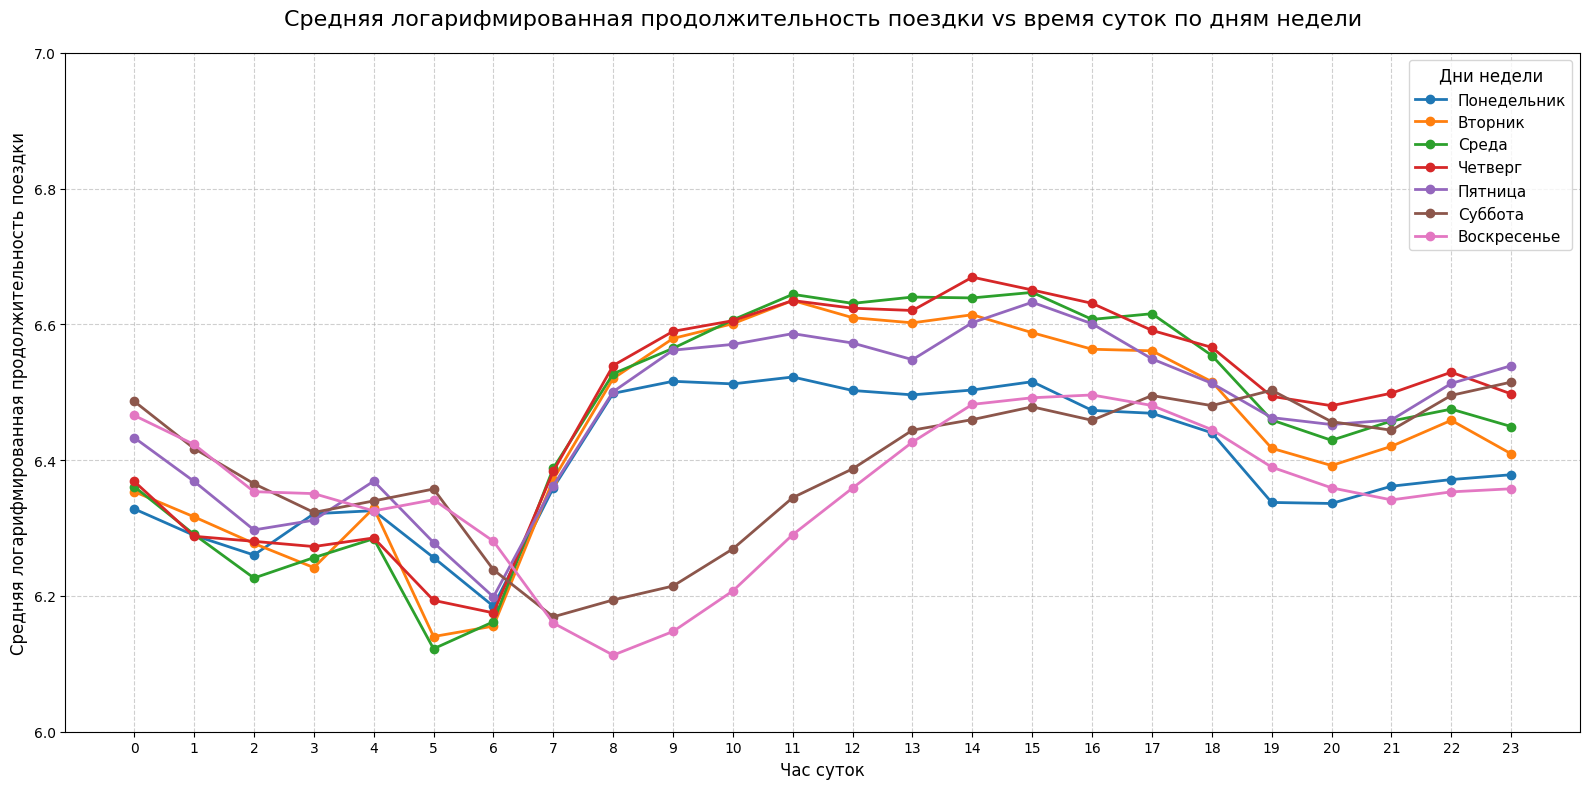

In [12]:

# Средняя продолжительность поездки vs время суток для каждого дня недели (например, нарисовав с разными цветами и, соответственно, легендами)

import matplotlib.pyplot as plt

# 1. Группируем данные одновременно по дням недели и часам, считая среднее
grouped_df = (
    processed_data.groupby(["day_of_week", "hour"], as_index=False)[
        "log_trip_duration"
    ]
    .mean()
)

# Словарь для красивых названий дней недели в легенде
days_names = {
    0: "Понедельник",
    1: "Вторник",
    2: "Среда",
    3: "Четверг",
    4: "Пятница",
    5: "Суббота",
    6: "Воскресенье",
}

# 2. Создаем полотно для графика
fig, ax = plt.subplots(figsize=(16, 8))

# 3. В цикле перебираем каждый день недели и строим для него отдельную линию
for day in sorted(grouped_df["day_of_week"].unique()):
    # Фильтруем данные только для текущего дня
    day_data = grouped_df[grouped_df["day_of_week"] == day]

    # Строим линию (ось X - часы, ось Y - средняя длительность)
    ax.plot(
        day_data["hour"],
        day_data["log_trip_duration"],
        marker="o",  # Добавит точки на каждый час
        linewidth=2,  # Толщина линии
        label=days_names.get(
            day, f"День {day}"
        ),  # Понятное имя для легенды
    )

# 4. Настраиваем внешний вид графика
ax.set_title(
    "Средняя логарифмированная продолжительность поездки vs время суток по дням недели",
    fontsize=16,
    pad=20,
)
ax.set_xlabel("Час суток", fontsize=12)
ax.set_ylabel(
    "Средняя логарифмированная продолжительность поездки", fontsize=12
)

# Задаем засечки на оси X от 0 до 23, чтобы каждый час было видно
ax.set_xticks(range(24))

# Ограничиваем ось Y для лучшей наглядности динамики (диапазон можно настроить под ваши данные)
ax.set_ylim((6, 7))

# Включаем сетку, чтобы было удобно сравнивать значения
ax.grid(True, linestyle="--", alpha=0.6)

# Отображаем легенду (размещаем ее в оптимальном пустом месте)
ax.legend(title="Дни недели", fontsize=11, title_fontsize=12, loc="best")

plt.tight_layout()
plt.show()

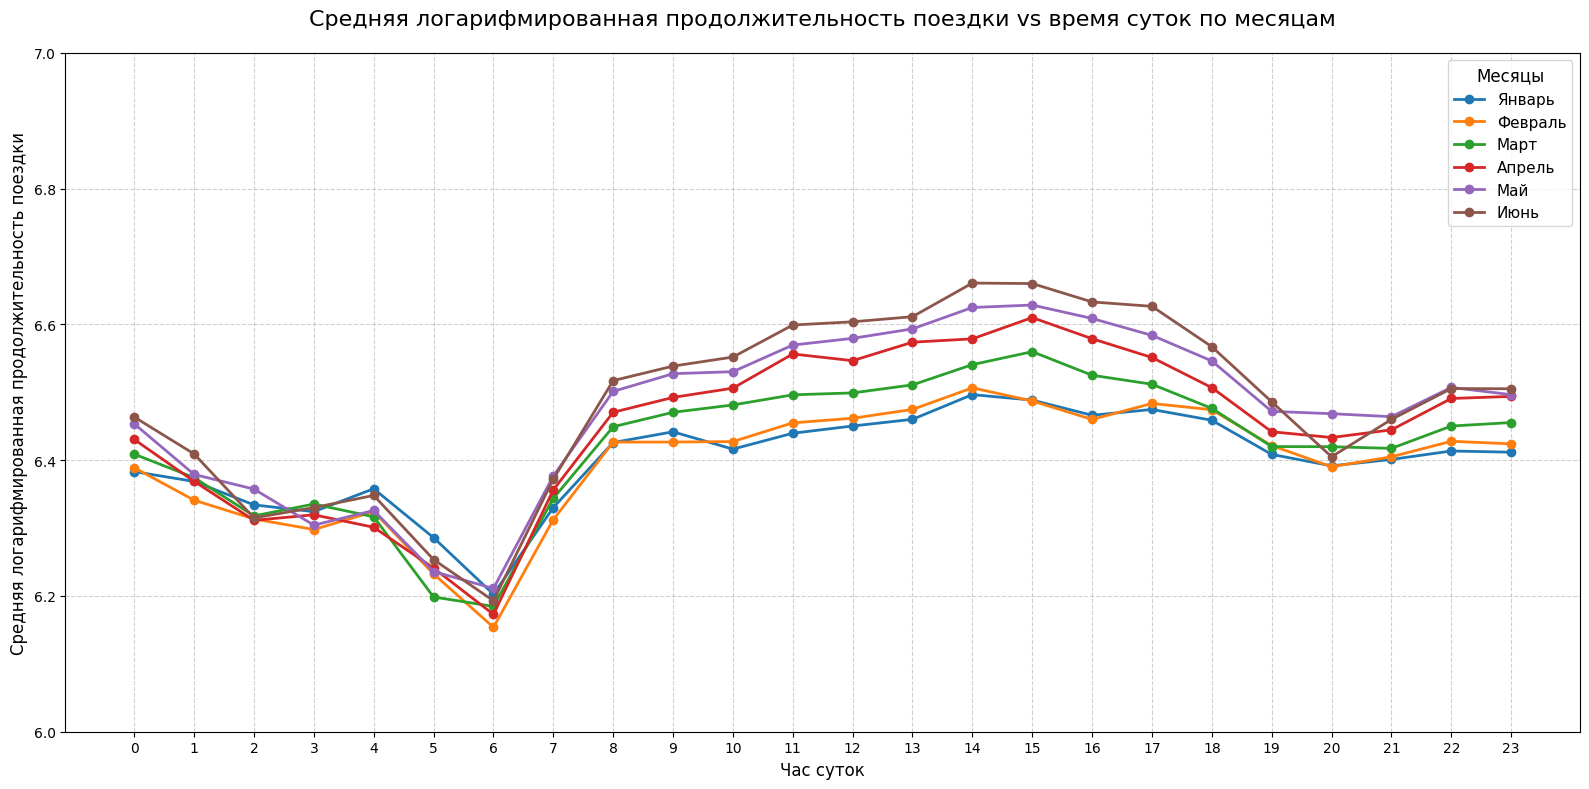

In [13]:
import matplotlib.pyplot as plt

# 1. Группируем данные одновременно по месяцам и часам, считая среднее
grouped_months_df = (
    processed_data.groupby(["month", "hour"], as_index=False)[
        "log_trip_duration"
    ]
    .mean()
)

# Словарь для красивых названий месяцев в легенде
months_names = {
    1: "Январь",
    2: "Февраль",
    3: "Март",
    4: "Апрель",
    5: "Май",
    6: "Июнь",
    7: "Июль",
    8: "Август",
    9: "Сентябрь",
    10: "Октябрь",
    11: "Ноябрь",
    12: "Декабрь",
}

# 2. Создаем полотно для графика
fig, ax = plt.subplots(figsize=(16, 8))

# 3. В цикле перебираем каждый уникальный месяц и строим для него отдельную линию
for month in sorted(grouped_months_df["month"].unique()):
    # Фильтруем данные только для текущего месяца
    month_data = grouped_months_df[grouped_months_df["month"] == month]

    # Строим линию (ось X - часы, ось Y - средняя длительность)
    ax.plot(
        month_data["hour"],
        month_data["log_trip_duration"],
        marker="o",  # Добавит точки на каждый час
        linewidth=2,  # Толщина линии
        label=months_names.get(
            month, f"Месяц {month}"
        ),  # Понятное имя для легенды
    )

# 4. Настраиваем внешний вид графика
ax.set_title(
    "Средняя логарифмированная продолжительность поездки vs время суток по месяцам",
    fontsize=16,
    pad=20,
)
ax.set_xlabel("Час суток", fontsize=12)
ax.set_ylabel(
    "Средняя логарифмированная продолжительность поездки", fontsize=12
)

# Задаем засечки на оси X от 0 до 23 (каждый час суток)
ax.set_xticks(range(24))

# Ограничиваем ось Y под масштаб ваших данных (измените границы, если линии не помещаются)
ax.set_ylim((6, 7))

# Включаем пунктирную сетку для удобства анализа
ax.grid(True, linestyle="--", alpha=0.6)

# Отображаем легенду со списком месяцев
ax.legend(title="Месяцы", fontsize=11, title_fontsize=12, loc="best")

plt.tight_layout()
plt.show()

C:\Users\Max\AppData\Local\Temp\ipykernel_6516\3035498050.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Max\AppData\Local\Temp\ipykernel_6516\3035498050.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Max\AppData\Local\Temp\ipykernel_6516\3035498050.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(
C:\Users\Max\AppData\Local\Temp\ipykernel_6516\3035498050.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.

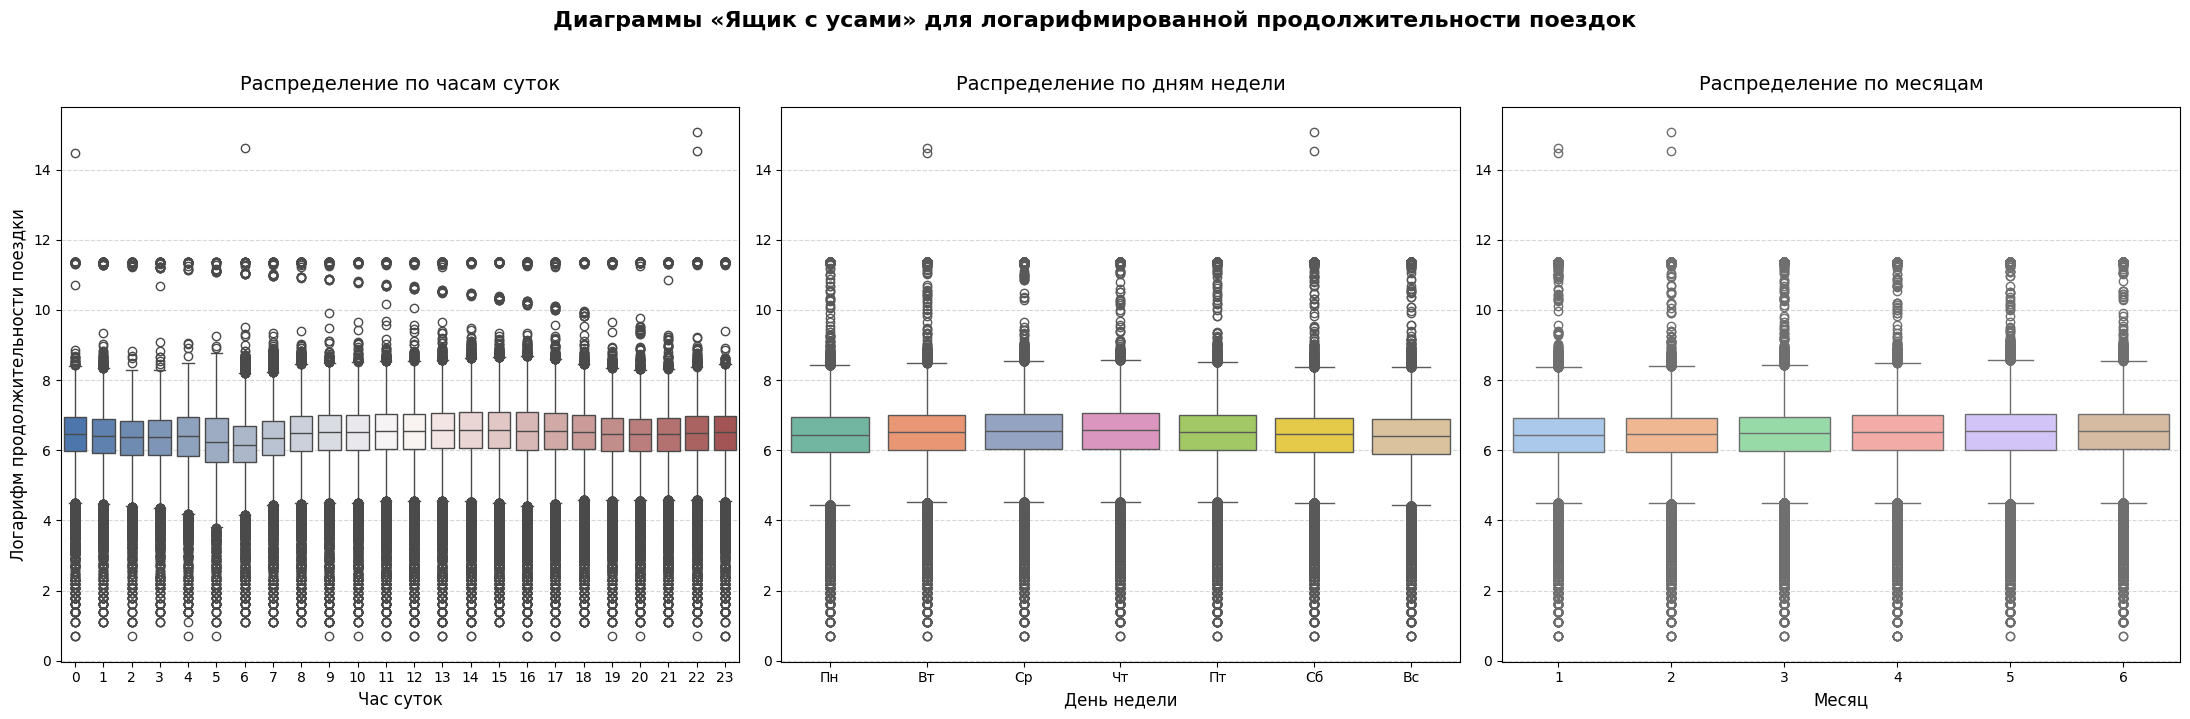

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Создаем полотно из 3 графиков в один ряд
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Словарь для красивых подписей дней недели на графике
days_names = [
    "Пн",
    "Вт",
    "Ср",
    "Чт",
    "Пт",
    "Сб",
    "Вс",
]  # для 0,1,2,3,4,5,6

# 2. ГРАФИК №1: По времени суток (Часы)
sns.boxplot(
    data=processed_data,
    x="hour",
    y="log_trip_duration",
    ax=axes[0],
    palette="vlag",
)
axes[0].set_title("Распределение по часам суток", fontsize=14, pad=12)
axes[0].set_xlabel("Час суток", fontsize=12)
axes[0].set_ylabel(
    "Логарифм продолжительности поездки", fontsize=12
)  # ставим подпись только слева
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# 3. ГРАФИК №2: По дням недели
sns.boxplot(
    data=processed_data,
    x="day_of_week",
    y="log_trip_duration",
    ax=axes[1],
    palette="Set2",
)
axes[1].set_title("Распределение по дням недели", fontsize=14, pad=12)
axes[1].set_xlabel("День недели", fontsize=12)
axes[1].set_ylabel("")  # убираем дублирующую подпись
axes[1].set_xticklabels(
    days_names
)  # заменяем цифры 0-6 на Пн-Вс для читаемости
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# 4. ГРАФИК №3: По месяцам
sns.boxplot(
    data=processed_data,
    x="month",
    y="log_trip_duration",
    ax=axes[2],
    palette="pastel",
)
axes[2].set_title("Распределение по месяцам", fontsize=14, pad=12)
axes[2].set_xlabel("Месяц", fontsize=12)
axes[2].set_ylabel("")  # убираем дублирующую подпись
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

# 5. Общие настройки отображения
# При необходимости раскомментируйте строку ниже, чтобы обрезать ось Y (если выбросы слишком растягивают график)
# for ax in axes: ax.set_ylim((4, 9))

plt.suptitle(
    "Диаграммы «Ящик с усами» для логарифмированной продолжительности поездок",
    fontsize=16,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

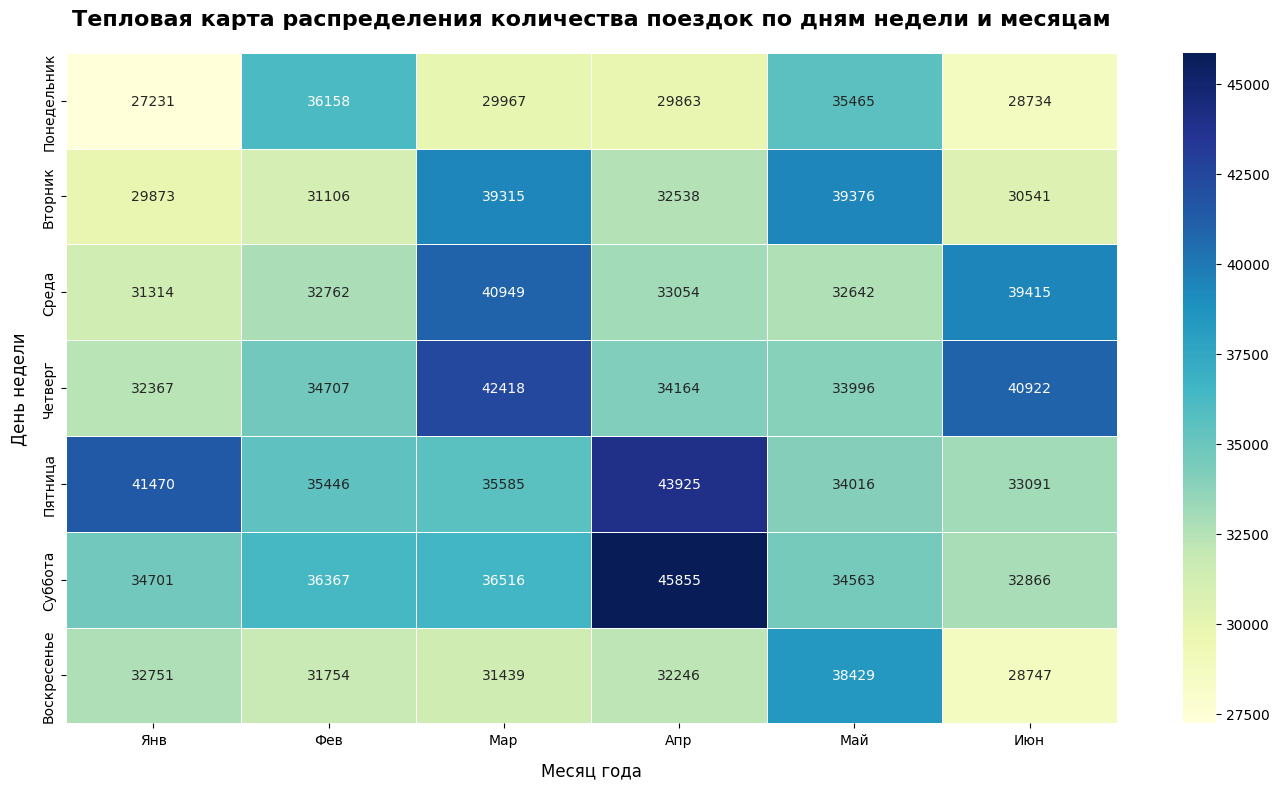

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Строим сводную таблицу: считаем количество поездок (размер групп) для каждой комбинации дня и месяца
pivot_table = processed_data.pivot_table(
    index="day_of_week",
    columns="month",
    aggfunc="size",  # Находит общее число строк (поездок)
    fill_value=0,  # Заменяет пустоты нулями, если в какой-то день не было поездок
)

# 2. Задаем красивые текстовые подписи для осей
days_labels = [
    "Понедельник",
    "Вторник",
    "Среда",
    "Четверг",
    "Пятница",
    "Суббота",
    "Воскресенье",
]
months_labels = [
    "Янв",
    "Фев",
    "Мар",
    "Апр",
    "Май",
    "Июн",
    "Июл",
    "Авг",
    "Сен",
    "Окт",
    "Ноя",
    "Дек",
]

# Фильтруем названия месяцев под те, что реально есть в ваших данных (если у вас данные не за весь год)
existing_months = [months_labels[m - 1] for m in pivot_table.columns]

# 3. Настраиваем график
plt.figure(figsize=(14, 8))

# Строим тепловую карту
sns.heatmap(
    pivot_table,
    annot=True,  # Выводит конкретное число поездок внутри каждой ячейки
    fmt="d",  # Формат вывода чисел — целое число (integer)
    cmap="YlGnBu",  # Красивая палитра: от светло-желтого (мало) до темно-синего (много)
    xticklabels=existing_months,
    yticklabels=days_labels,
    linewidths=0.5,  # Добавляет аккуратные сетчатые границы между ячейками
)

# 4. Оформление заголовков
plt.title(
    "Тепловая карта распределения количества поездок по дням недели и месяцам",
    fontsize=16,
    pad=20,
    weight="bold",
)
plt.xlabel("Месяц года", fontsize=12, labelpad=10)
plt.ylabel("День недели", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

Кажется, что полученные выводы из графиков выше достаточны для того, чтобы посчитать признаки, связанные с временем/датой поездки, достаточно важными. На их основе выделим еще пару.

Добавьте следующие бинарные признаки:


1. Была ли в день поездки буря (основываясь на единственном обнаруженном таком дне)
2. Является ли время поездки статистически самым проблемным, то есть час пиком?

Для создания 2ой фичи используйте следующую логику: посчитаем для каждой пары "день недели"-"время суток" среднее значение таргета. Найдем топ-10 самых "больших" пар. Если поездка была совершена во входящее в этот топ время, то ставим 1. Иначе - 0. Получается бинарный признак.

P.S. назовите колонки **anomaly** и **traffic_jam**

In [16]:
### Создадим первый бинарный признак
### Your code is here
dates = pd.to_datetime(processed_data['date'])
processed_data['anomaly'] = dates.between('2016-01-23', '2016-01-24').astype(int)

In [17]:
### Создадим второй бинарный признак
### Your code is here
top_10_pairs = (
    processed_data
    .groupby(['day_of_week', 'hour'])['log_trip_duration']
    .mean()
    .nlargest(10)
    .index
)
pairs = pd.MultiIndex.from_frame(processed_data[['day_of_week', 'hour']])
processed_data['traffic_jam'] = pairs.isin(top_10_pairs).astype(int)

In [18]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,pickup_datetime,date,day_of_week,hour,month,anomaly,traffic_jam
id,,,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,2016-03-14 17:24:55,2016-03-14,0,17,3,0,0
id2377394,0,930.399753,0,1.807119,6.498282,2016-06-12 00:43:35,2016-06-12,6,0,6,0,0
id3858529,1,930.399753,0,6.392080,7.661527,2016-01-19 11:35:24,2016-01-19,1,11,1,0,1
id3504673,1,930.399753,0,1.487155,6.063785,2016-04-06 19:32:31,2016-04-06,2,19,4,0,0
id2181028,1,930.399753,0,1.189925,6.077642,2016-03-26 13:30:55,2016-03-26,5,13,3,0,0


Теперь колонки **pickup_datetime**, **date** можно убрать. А про оставшиеся **day_of_week**, **hour**, **month** необходимо подумать:

- С одной стороны, первые две можно убрать, так как на их основе была создана колонка **traffic_jam**
- С другой стороны, зависимость с колонкой **traffic_jam** нелинейная, поэтому можно попробовать использовать все фичи в комбинации. Конечно, лучше попробовать оба варианта и проэкспериментировать, но ради упрощения - оставим все колонки. Хоть **day_of_week**, **hour** и описываются числами, мы понимаем, что это скорее категориальные фичи. Потому что, например, отношение между 23:00 и 00:00 не такое же, как между числами 23 и 0. Закодируем их с помощью OneHotEncoder. 
- Последняя (**month**) очевидно категориальная. Можно закодировать ее тоже через OneHotEncoder.

In [19]:
processed_data = processed_data.drop(['pickup_datetime', 'date'], axis=1)

In [20]:
### Делаем OneHotEncoding и конкатим с processed_data

from sklearn.preprocessing import OneHotEncoder

for col in ['day_of_week', 'hour', 'month']:
    encoder = OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse_output=True,
        dtype=int
    )
    encoded = encoder.fit_transform(processed_data[[col]])

    encoded_df = pd.DataFrame.sparse.from_spmatrix(
        encoded,
        index=processed_data.index,
        columns=encoder.get_feature_names_out([col])
    )

    processed_data = pd.concat(
        [processed_data.drop(columns=[col]), encoded_df],
        axis=1
    )

In [21]:
processed_data = processed_data.apply(
    lambda x: x.astype('int8') if x.dtype == 'bool' else x
)
processed_data.head()


,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,anomaly,traffic_jam,day_of_week_1,day_of_week_2,day_of_week_3,...,hour_19,hour_20,hour_21,hour_22,hour_23,month_2,month_3,month_4,month_5,month_6
id,,,,,,,,,,,,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
id2377394,0,930.399753,0,1.807119,6.498282,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
id3858529,1,930.399753,0,6.392080,7.661527,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
id3504673,1,930.399753,0,1.487155,6.063785,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
id2181028,1,930.399753,0,1.189925,6.077642,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [22]:
processed_data.dtypes

vendor_id                        int64
passenger_count                float64
store_and_fwd_flag               int64
distance_km                    float64
log_trip_duration              float64
anomaly                          int64
traffic_jam                      int64
day_of_week_1         Sparse[int64, 0]
day_of_week_2         Sparse[int64, 0]
day_of_week_3         Sparse[int64, 0]
day_of_week_4         Sparse[int64, 0]
day_of_week_5         Sparse[int64, 0]
day_of_week_6         Sparse[int64, 0]
hour_1                Sparse[int64, 0]
hour_2                Sparse[int64, 0]
hour_3                Sparse[int64, 0]
hour_4                Sparse[int64, 0]
hour_5                Sparse[int64, 0]
hour_6                Sparse[int64, 0]
hour_7                Sparse[int64, 0]
hour_8                Sparse[int64, 0]
hour_9                Sparse[int64, 0]
hour_10               Sparse[int64, 0]
hour_11               Sparse[int64, 0]
hour_12               Sparse[int64, 0]
hour_13               Spa

In [23]:
processed_data[:5].to_csv('processed_data4.csv',sep=',')

Что же, мы с Вами научились с помощью EDA визуализаций понимать важность признаков не только постфактум, но и до того, как сформировался финальный датасет - на этапе **выделения базовых фичей**.

Обратимся теперь к методам фильтрации - например, применим корреляционный анализ для одной пары фичей, чтобы понять, нет ли относительно этих колонок в нашем датасете избытка информации. 

Вспомним так же изначальные вещественные признаки - distance_km, passenger_count

Посчитайте корреляцию между ними. Есть ли какие-то основания для беспокойства?

In [26]:
### Your code is here

corr1 = processed_data[['distance_km', 'passenger_count']].corr().loc[
    'distance_km', 'passenger_count'
]
print(f"Correlation between distance_km and passenger_count: {corr1:.3f}")

Correlation between distance_km and passenger_count: 0.017


In [27]:
processed_data.head()

,vendor_id,passenger_count,store_and_fwd_flag,distance_km,log_trip_duration,anomaly,traffic_jam,day_of_week_1,day_of_week_2,day_of_week_3,...,hour_19,hour_20,hour_21,hour_22,hour_23,month_2,month_3,month_4,month_5,month_6
id,,,,,,,,,,,,,,,,,,,,,
id2875421,1,930.399753,0,1.500479,6.122493,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
id2377394,0,930.399753,0,1.807119,6.498282,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
id3858529,1,930.399753,0,6.392080,7.661527,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
id3504673,1,930.399753,0,1.487155,6.063785,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
id2181028,1,930.399753,0,1.189925,6.077642,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [28]:
### На данный момент у нас 41 фича
### Представим, что хочется сократить их количество до 5.
### Воспользуемся для этим каким-нибудь методом обертки
### Например, метод прямого отбора
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
### Your code is here

model = LinearRegression()
sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction='forward')

sfs.fit(processed_data.drop(columns=['log_trip_duration']), processed_data['log_trip_duration'])


e:\python_projects\ML_course_karpov\env\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


,estimator,LinearRegression()
,n_features_to_select,5
,tol,None
,direction,'forward'
,scoring,None
,cv,5
,n_jobs,None
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [29]:
### Перечислите фичи, которые окажутся наиболее желанными
### Your code is here
sfs.get_feature_names_out()

array(['distance_km', 'traffic_jam', 'day_of_week_6', 'hour_5', 'hour_6'],
      dtype=object)

In [ ]:
### Представим, что мы с Вами ничего не знаем про Кросс-Валидацию и отложенную выборку
### Замерьте качество линейной регрессии на данных фичах
### Сильно ли оно отличается от полученного на Кросс-Валидации в прошлом уроке в ДЗ?
from sklearn.metrics import mean_squared_error

features = list(sfs.get_feature_names_out())

X = processed_data[features]
y = processed_data['log_trip_duration']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
print('MSE:', mse)



e:\python_projects\ML_course_karpov\env\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


MSE: 0.41540002340782556


e:\python_projects\ML_course_karpov\env\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
